# Weekly ETF Risk Monitor: end-to-end project pipeline

**Author:** Paritosh Dwivedi

## Objective and stakeholder question

This notebook builds a reproducible SPY risk-monitoring pipeline for a portfolio manager's weekly review.

**Decision question:** Should the portfolio manager maintain the current SPY exposure or investigate reducing it because near-term risk appears elevated?

**Success criteria:** validated immutable raw data, reproducible processed data, chronological out-of-sample evaluation, a clear current risk signal, and explicit assumptions and limitations.

In [1]:
# --- run me first: makes this notebook work wherever it lives ---
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display

from run_pipeline import run
from src.config import get_settings

settings = get_settings()
print("working from:", ROOT.name)
print("author: Paritosh Dwivedi")

working from: project
author: Paritosh Dwivedi


## Analysis plan

1. Acquire or reload a recorded daily SPY snapshot.
2. Validate schema, types, missingness, duplicates, ordering, and price ranges.
3. Clean without modifying the raw artifact.
4. Retain plausible tail observations and flag extreme returns.
5. Build lagged and rolling features without look-ahead.
6. Predict five-day realized volatility with Ridge regression.
7. Classify elevated-risk forecast windows using a training-derived threshold and a documented score cutoff.
8. Purge five sessions between training and holdout targets.
9. Compare with baselines, non-overlapping samples, walk-forward folds, and sensitivity checks.
10. Refit production models on all labeled history and translate the latest result into a stakeholder signal.

The smallest complete baseline is executed before any optional model expansion.

## 1. Execute the complete reproducible pipeline

The default run uses the latest validated raw snapshot. Pass `refresh=True` only when a new provider pull is intended; each refresh creates a new immutable raw file.

In [2]:
metrics = run(refresh=False)
print("pipeline completed for:", metrics["ticker"])
print("generated at:", metrics["generated_at_utc"])

pipeline completed for: SPY
generated at: 2026-08-28T11:23:25.925974+00:00


## 2. Data source and validation

In [3]:
data_summary = {
    "provider": metrics["data"]["acquisition"].get("provider"),
    "raw_file": metrics["data"]["raw_file"],
    "rows": metrics["data"]["rows_raw"],
    "date_start": metrics["data"]["date_start"],
    "date_end": metrics["data"]["date_end"],
    "validation_passed": metrics["data"]["raw_validation"]["valid"],
    "missing_values": metrics["data"]["raw_validation"]["missing_values"],
    "duplicate_dates": metrics["data"]["raw_validation"]["duplicate_dates"],
}
pd.Series(data_summary, name="value").to_frame()

,value
provider,yfinance
raw_file,data/raw/spy_daily_20260826T030031701985Z.csv
rows,4186
date_start,2010-01-04
date_end,2026-08-25
validation_passed,True
missing_values,0
duplicate_dates,0


The raw file is preserved under `data/raw/` with a retrieval timestamp and SHA-256 manifest. Processed outputs are derived by code and can be regenerated.

In [4]:
processed = pd.read_parquet(ROOT / metrics["data"]["model_dataset_file"])
display(
    processed[
        [
            "date",
            "adjusted_close",
            "daily_return",
            "rolling_vol_20",
            "drawdown",
            "target_next_week_vol",
        ]
    ].tail()
)
print("processed rows:", len(processed))
print("flagged retained return outliers:", metrics["data"]["return_outliers_flagged"])

,date,adjusted_close,daily_return,rolling_vol_20,drawdown,target_next_week_vol
4181,2026-08-19,769.059998,0.002098,0.135949,-0.011339,NaN
4182,2026-08-20,762.599976,-0.008400,0.131211,-0.019643,NaN
4183,2026-08-21,765.719971,0.004091,0.131473,-0.015632,NaN
4184,2026-08-24,763.469971,-0.002938,0.132446,-0.018525,NaN
4185,2026-08-25,765.909973,0.003196,0.132538,-0.015388,NaN


processed rows: 4186
flagged retained return outliers: 31


## 3. Storage layer round trip

This section exercises `src/storage.py` directly so the Stage 05 storage work is visible rather than hidden inside the pipeline call. Directories come from `.env` through `get_settings()`, so no absolute path is written anywhere.

In [5]:
from src.storage import read_dataframe, write_dataframe

print("raw directory     :", settings.raw_dir.relative_to(ROOT))
print("processed directory:", settings.processed_dir.relative_to(ROOT))

storage_demo = (
    processed[["date", "adjusted_close", "rolling_vol_20"]].tail(5).reset_index(drop=True)
)
# A categorical column makes the format contrast visible: Parquet stores the schema,
# CSV stores only text and leaves pandas to guess on the way back in.
storage_demo["risk_band"] = pd.Categorical(
    ["normal", "normal", "elevated", "normal", "elevated"],
    categories=["normal", "elevated"],
)
demo_csv = write_dataframe(storage_demo, settings.processed_dir / "storage_roundtrip_demo.csv")
demo_parquet = write_dataframe(
    storage_demo, settings.processed_dir / "storage_roundtrip_demo.parquet"
)
print("wrote:", demo_csv.name, "and", demo_parquet.name)

raw directory     : data/raw
processed directory: data/processed
wrote: storage_roundtrip_demo.csv and storage_roundtrip_demo.parquet


In [6]:
from_csv = read_dataframe(demo_csv)
from_parquet = read_dataframe(demo_parquet)

print("shapes match original:", from_csv.shape == storage_demo.shape == from_parquet.shape)
display(
    pd.DataFrame(
        {
            "original": storage_demo.dtypes.astype(str),
            "from_csv": from_csv.dtypes.astype(str),
            "from_parquet": from_parquet.dtypes.astype(str),
        }
    )
)

shapes match original: True


,original,from_csv,from_parquet
date,datetime64[ns],datetime64[ns],datetime64[ns]
adjusted_close,float64,float64,float64
rolling_vol_20,float64,float64,float64
risk_band,category,object,category


Both formats reload to the same shape, but not to the same schema. Parquet stores the dtypes alongside the values, so `risk_band` returns as a category. CSV stores text, so the same column returns as a plain object and the ordered category is gone; the date survives only because `read_dataframe` parses that column by convention.

That difference is the reason for the split: CSV stays the transparent, human-readable exchange format for `data/raw/`, and Parquet carries typed derived tables in `data/processed/` where dtype fidelity matters to the next stage.

## 4. Preprocessing transformations

This section applies `clean_market_data` from `src/cleaning.py` to the immutable raw snapshot and compares the table before and after. The raw file is only read; cleaning returns a new frame and never edits `data/raw/`.

In [7]:
from src.cleaning import clean_market_data

raw_frame = read_dataframe(ROOT / metrics["data"]["raw_file"])
cleaned_frame, cleaning_report = clean_market_data(raw_frame)

comparison = pd.DataFrame(
    {
        "raw": [
            len(raw_frame),
            int(raw_frame.isna().sum().sum()),
            int(raw_frame["date"].duplicated().sum()),
        ],
        "cleaned": [
            len(cleaned_frame),
            int(cleaned_frame.isna().sum().sum()),
            int(cleaned_frame["date"].duplicated().sum()),
        ],
    },
    index=["rows", "missing values", "duplicate dates"],
)
display(comparison)

,raw,cleaned
rows,4186,4186
missing values,0,0
duplicate dates,0,0


In [8]:
display(pd.Series(cleaning_report["policy"], name="cleaning policy").to_frame())
print("rows removed:", cleaning_report["rows_removed"])
print(
    "date range after cleaning:", cleaning_report["date_start"], "to", cleaning_report["date_end"]
)

,cleaning policy
0,Unparseable or incomplete required rows are re...
1,"Non-positive prices, negative volume, and inte..."
2,Duplicate dates retain the final provider record.
3,Missing adjusted close falls back to close.


rows removed: 0
date range after cleaning: 2010-01-04 to 2026-08-25


The recorded snapshot needs no repairs, which is the result a validated ingestion layer should produce. To show the transformations actually doing work, the cell below injects the four defect types the policy names into a throwaway copy. `data/raw/` is untouched.

In [9]:
damaged = raw_frame.copy()
damaged["date"] = damaged["date"].astype(object)  # allow a bad date to be written
damaged.loc[len(damaged)] = damaged.iloc[-1]  # duplicate date
damaged.iloc[0, damaged.columns.get_loc("close")] = -5.0  # non-positive price
damaged.iloc[1, damaged.columns.get_loc("volume")] = -100  # negative volume
damaged.iloc[2, damaged.columns.get_loc("high")] = 0.01  # high below low
damaged.iloc[3, damaged.columns.get_loc("date")] = "not-a-date"  # unparseable date

repaired, damage_report = clean_market_data(damaged)

display(
    pd.DataFrame(
        {
            "damaged": [len(damaged), int(damaged["date"].astype(str).duplicated().sum())],
            "repaired": [len(repaired), int(repaired["date"].duplicated().sum())],
        },
        index=["rows", "duplicate dates"],
    )
)
print("rows removed by the cleaner:", damage_report["rows_removed"])

,damaged,repaired
rows,4187,4182
duplicate dates,1,0


rows removed by the cleaner: 5


The cleaner removes all five defective rows and leaves the rest untouched, returning a new frame each time. The original `raw_frame` still has its full row count, which is what "copy-safe" means in practice.

**Assumptions made during cleaning.** Required fields must parse as dates and numbers, so unparseable rows are dropped rather than guessed. Non-positive prices, negative volume, and internally inconsistent OHLC rows are treated as provider errors, not market events. A duplicate date keeps the final provider record because later records reflect corrections. A missing adjusted close falls back to the close.

Extreme returns are a different matter and are deliberately **not** removed here. They are flagged in `src/outliers.py` and retained, because a monitor built to detect elevated risk would understate exactly the periods it exists to catch if its largest moves were deleted.

## 5. Outlier analysis

Stage 07 work, run directly from `src/outliers.py`. The parameters are fit on the purged training
window only, then applied to later rows, so the evaluation period never influences its own flag.

In [10]:
from src.outliers import add_return_outlier_flag, fit_return_outlier_parameters

train_returns = processed.loc[: metrics["models"]["train_rows"] - 1, "log_return"]
outlier_params = fit_return_outlier_parameters(train_returns)
flagged = add_return_outlier_flag(processed, parameters=outlier_params)

print("fitted on training rows only:", len(train_returns))
print(
    f"median {outlier_params.median:.6f} | MAD {outlier_params.mad:.6f}"
    f" | threshold {outlier_params.threshold:.1f}"
)
print("flagged observations:", int(flagged["return_outlier_flag"].sum()))

fitted on training rows only: 3339
median 0.000658 | MAD 0.004753 | threshold 6.0
flagged observations: 31


In [11]:
kept = flagged.loc[flagged["return_outlier_flag"] == 0, "daily_return"]
dropped = flagged.loc[flagged["return_outlier_flag"] == 1, "daily_return"]
display(
    pd.DataFrame(
        {
            "all observations": flagged["daily_return"].describe(),
            "excluding flagged": kept.describe(),
        }
    ).round(4)
)
print(f"largest flagged move: {dropped.abs().max() * 100:.2f}%")

,all observations,excluding flagged
count,4185.0000,4154.0000
mean,0.0006,0.0007
std,0.0108,0.0094
min,-0.1094,-0.0403
25%,-0.0037,-0.0036
50%,0.0007,0.0007
75%,0.0058,0.0058
max,0.1050,0.0433


largest flagged move: 10.94%


Excluding the flagged days barely moves the centre but visibly shrinks the tails, which is the point:
those days carry most of the risk information. They are flagged and kept, never dropped. The policy
and the risks of getting the threshold wrong are written up in `docs/outliers.md`.

## 6. Exploratory data analysis

Stage 08 work, run from `src/eda.py`. `eda_summary` profiles the frame without modifying it and
names the columns that should be resolved before feature engineering.

In [12]:
from src.eda import eda_summary

eda = eda_summary(processed)
print("shape:", eda["shape"])
print("columns with missing values:", {k: v for k, v in eda["missing"].items() if v})
display(
    eda["numeric_profile"]
    .loc[
        ["daily_return", "rolling_vol_5", "rolling_vol_20", "drawdown", "target_next_week_vol"],
        ["mean", "std", "min", "max", "skew", "kurtosis"],
    ]
    .round(4)
)

shape: (4186, 27)
columns with missing values: {'daily_return': 1, 'log_return': 1, 'return_lag_1': 2, 'return_lag_5': 6, 'rolling_return_5': 5, 'rolling_vol_5': 5, 'rolling_vol_20': 20, 'ewma_vol_20': 2, 'vol_ratio': 20, 'volume_z_20': 19, 'target_next_week_vol': 5, 'target_next_week_return': 5, 'return_outlier_score': 1}


,mean,std,min,max,skew,kurtosis
daily_return,0.0006,0.0108,-0.1094,0.1050,-0.3299,12.0129
rolling_vol_5,0.1373,0.1069,0.0068,1.4233,3.9984,30.6288
rolling_vol_20,0.1465,0.0909,0.0319,0.9392,3.5751,21.8647
drawdown,-0.0379,0.0502,-0.3372,0.0000,-1.8483,3.3758
target_next_week_vol,0.1381,0.1015,0.0131,1.3421,3.8849,29.0436


In [13]:
display(pd.Series(eda["attention"], name="columns").to_frame())

,columns
high_missing,[]
near_zero_variance,"[stock_splits, forecast_horizon_days, short_fe..."
dominant_category,[]


Daily returns are mildly left skewed with kurtosis far above the normal value of zero, which is the
statistical statement of fat tails and the reason the outlier policy exists. Realized volatility is
strongly right skewed: most weeks are calm and a few are not, so the mean overstates the typical
week. The flagged columns are constants that record the run configuration, not measurements, so they
are correctly excluded from the feature set.

## 7. Feature engineering

Stage 09 work, run from `src/features.py`. Every feature uses contemporaneous or past information
only, so nothing here can see the forecast window it is trying to predict.

In [14]:
from src.features import build_features

# The pipeline builds features first, then attaches the outlier flag, so mirror
# that order here or the flag is missing from the model's feature list.
engineered = add_return_outlier_flag(build_features(cleaned_frame), parameters=outlier_params)
feature_columns = metrics["models"]["feature_columns"]
print("engineered rows:", len(engineered))
print("features used by the model:", len(feature_columns))
display(engineered[feature_columns].tail(3).round(4))

engineered rows: 4186
features used by the model: 10


,return_lag_1,return_lag_5,rolling_return_5,rolling_vol_5,rolling_vol_20,ewma_vol_20,vol_ratio,drawdown,volume_z_20,return_outlier_flag
4183,-0.0084,-0.0020,-0.0137,0.0879,0.1315,0.1135,0.6687,-0.0156,-0.5610,0
4184,0.0041,-0.0047,-0.0119,0.0863,0.1324,0.1091,0.6514,-0.0185,-1.0376,0
4185,-0.0029,-0.0068,-0.0020,0.0833,0.1325,0.1049,0.6288,-0.0154,-1.3124,0


In [15]:
correlations = (
    engineered[feature_columns + ["target_next_week_vol"]]
    .corr()["target_next_week_vol"]
    .drop("target_next_week_vol")
    .sort_values(ascending=False)
)
display(correlations.round(3).to_frame("correlation with next-week volatility"))

,correlation with next-week volatility
ewma_vol_20,0.633
rolling_vol_5,0.627
rolling_vol_20,0.588
return_outlier_flag,0.381
volume_z_20,0.182
vol_ratio,0.173
return_lag_5,-0.105
return_lag_1,-0.174
rolling_return_5,-0.359
drawdown,-0.589


The trailing volatility measures correlate most strongly with next-week realized volatility, which is
what makes the recent-volatility baseline hard to beat. Drawdown and standardized volume add a
different kind of information: they rise in stressed markets that trailing volatility has not caught
up with yet. Feature definitions and the reasoning behind each one are tabulated in `README.md`.

## 8. Market and risk context

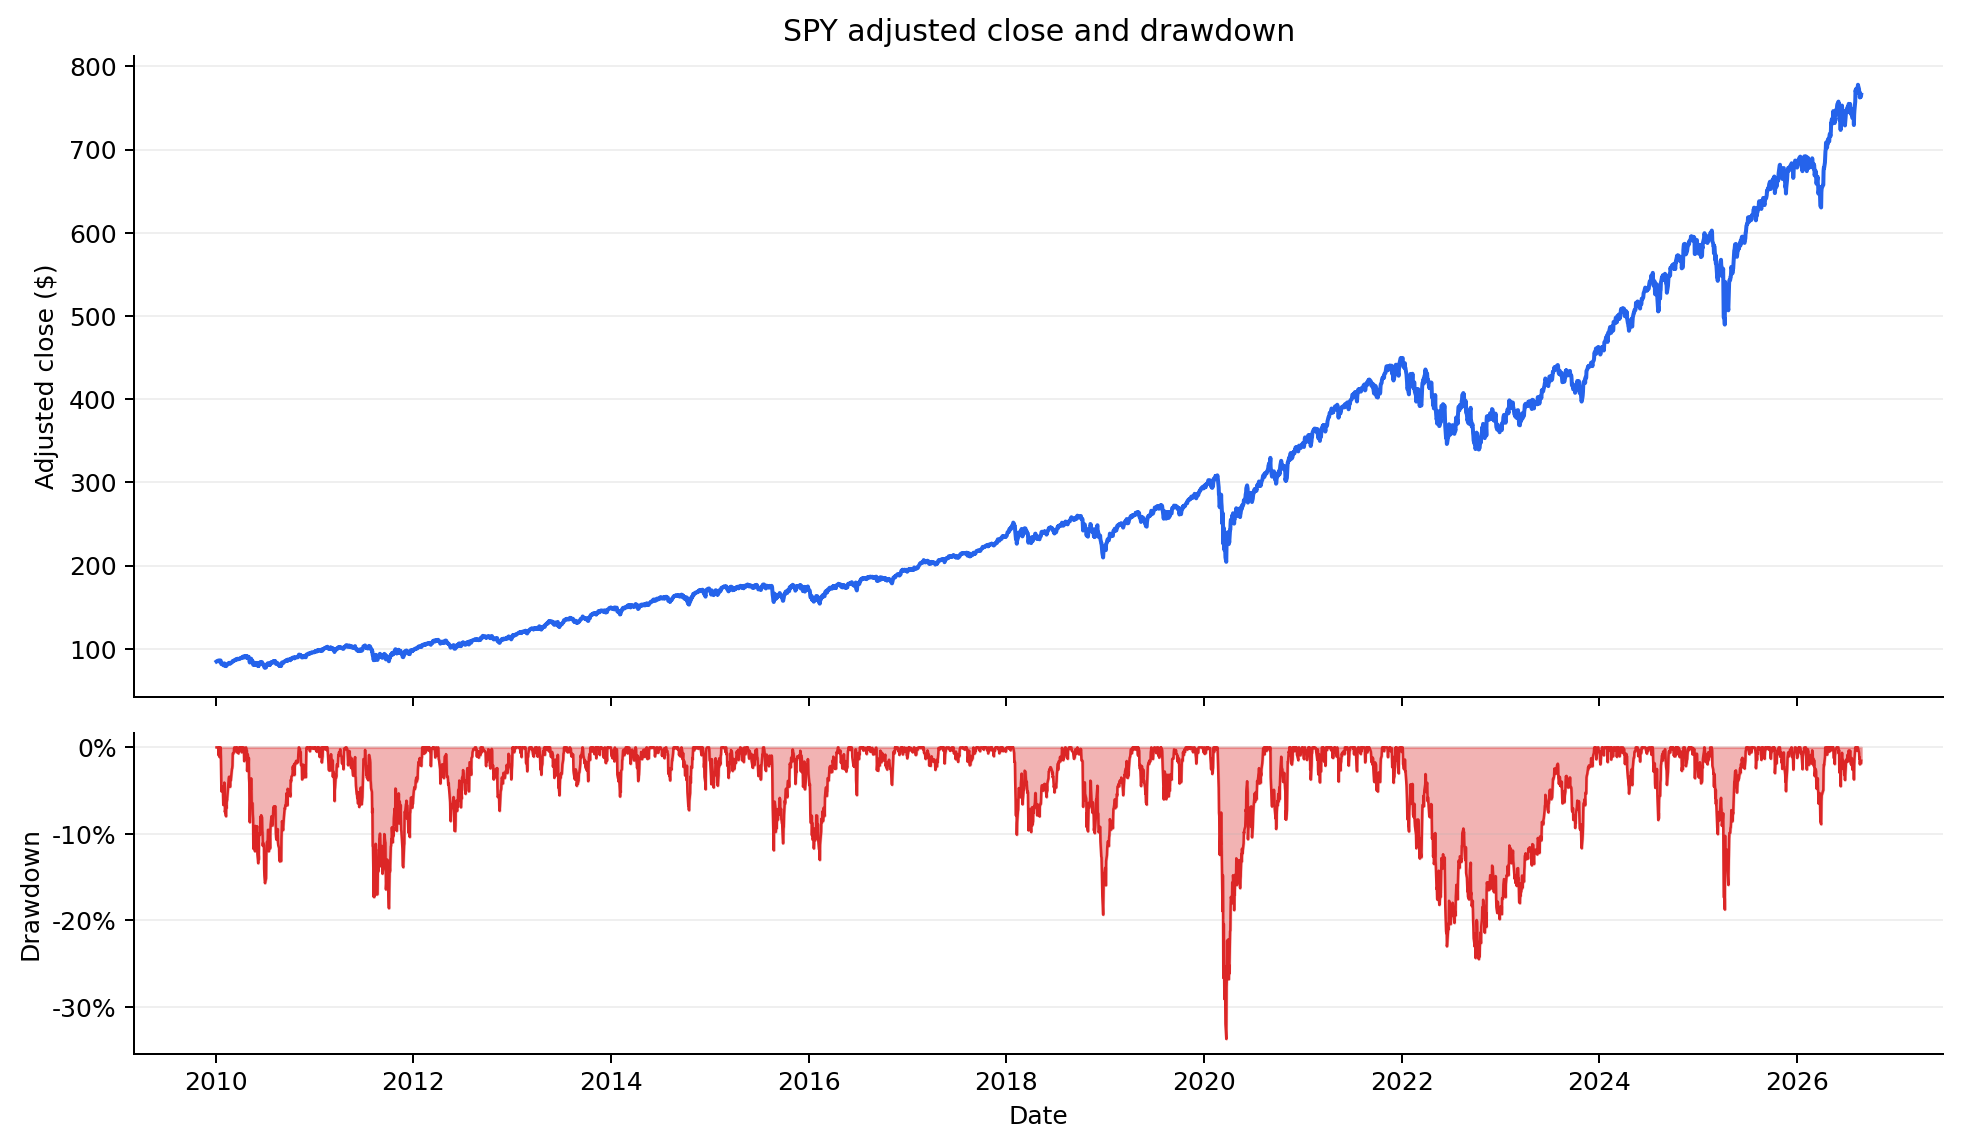

In [16]:
display(Image(filename=str(ROOT / "reports/images/price_and_drawdown.png"), width=900))

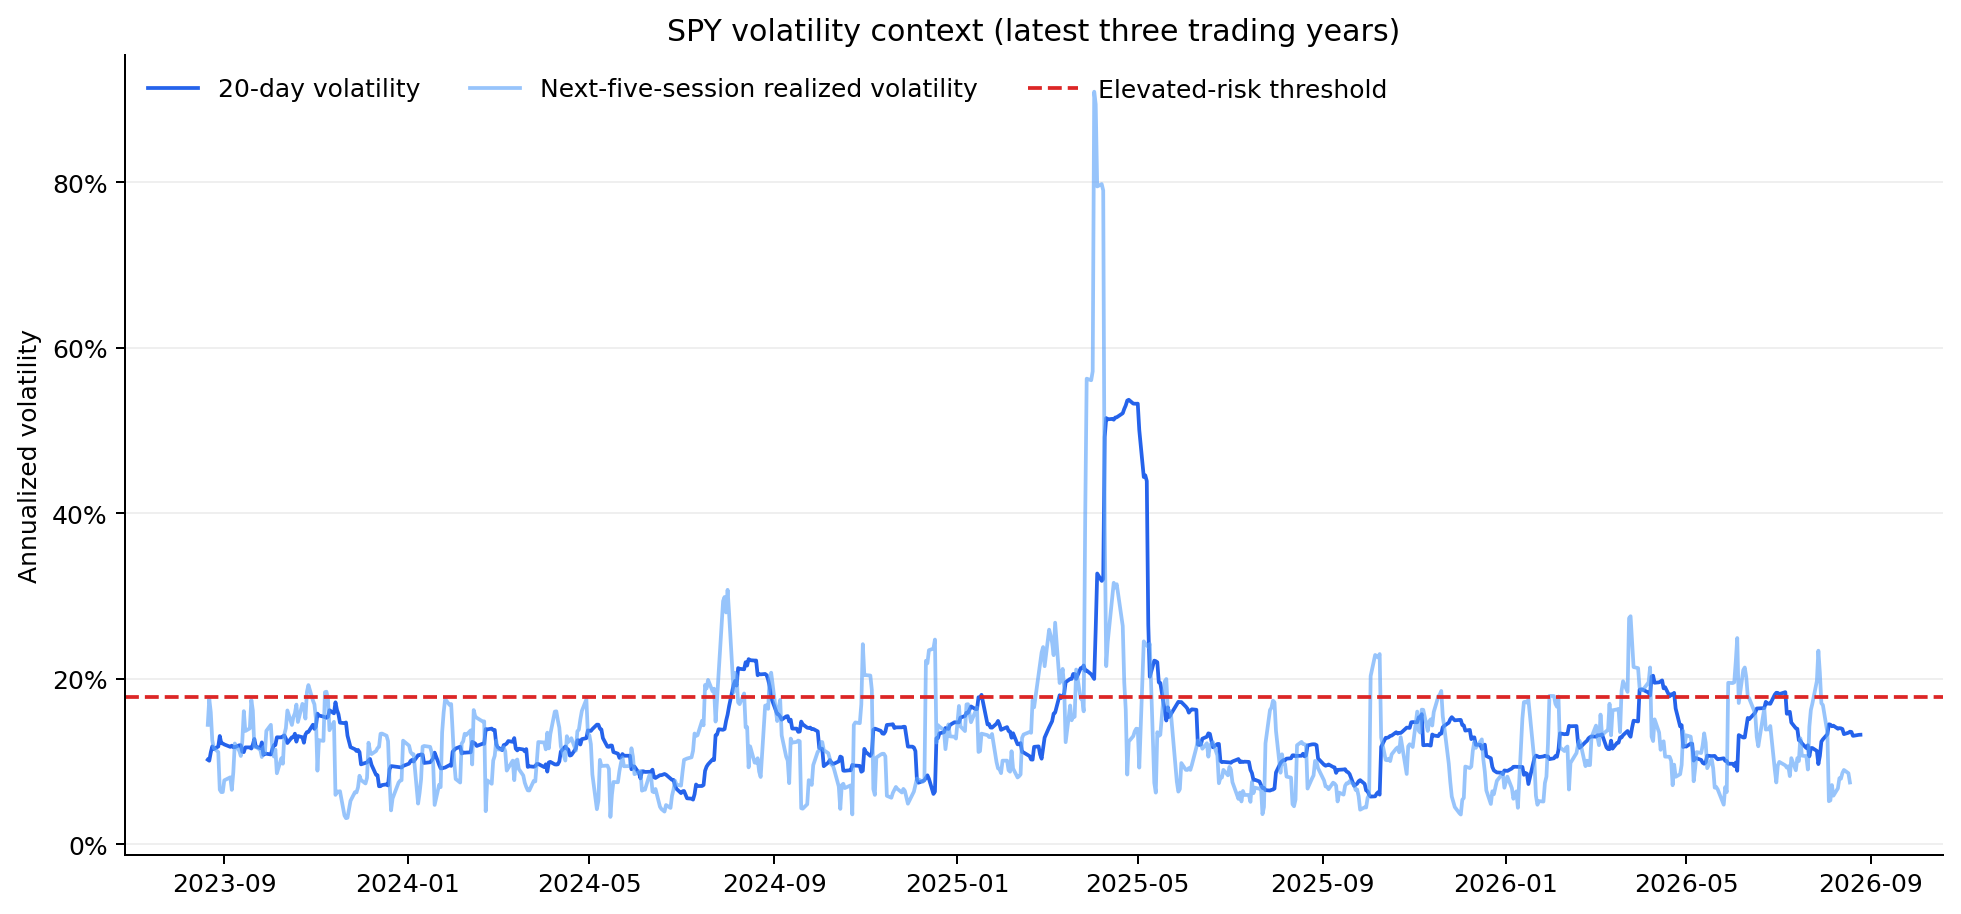

In [17]:
display(Image(filename=str(ROOT / "reports/images/volatility_and_risk_threshold.png"), width=900))

Plausible extremes are retained because tail events are central to risk decisions. Robust outlier location and scale are fit only on the allowed training history during evaluation, then refit on all labeled history for production scoring. The flag supports diagnosis without deleting market stress.

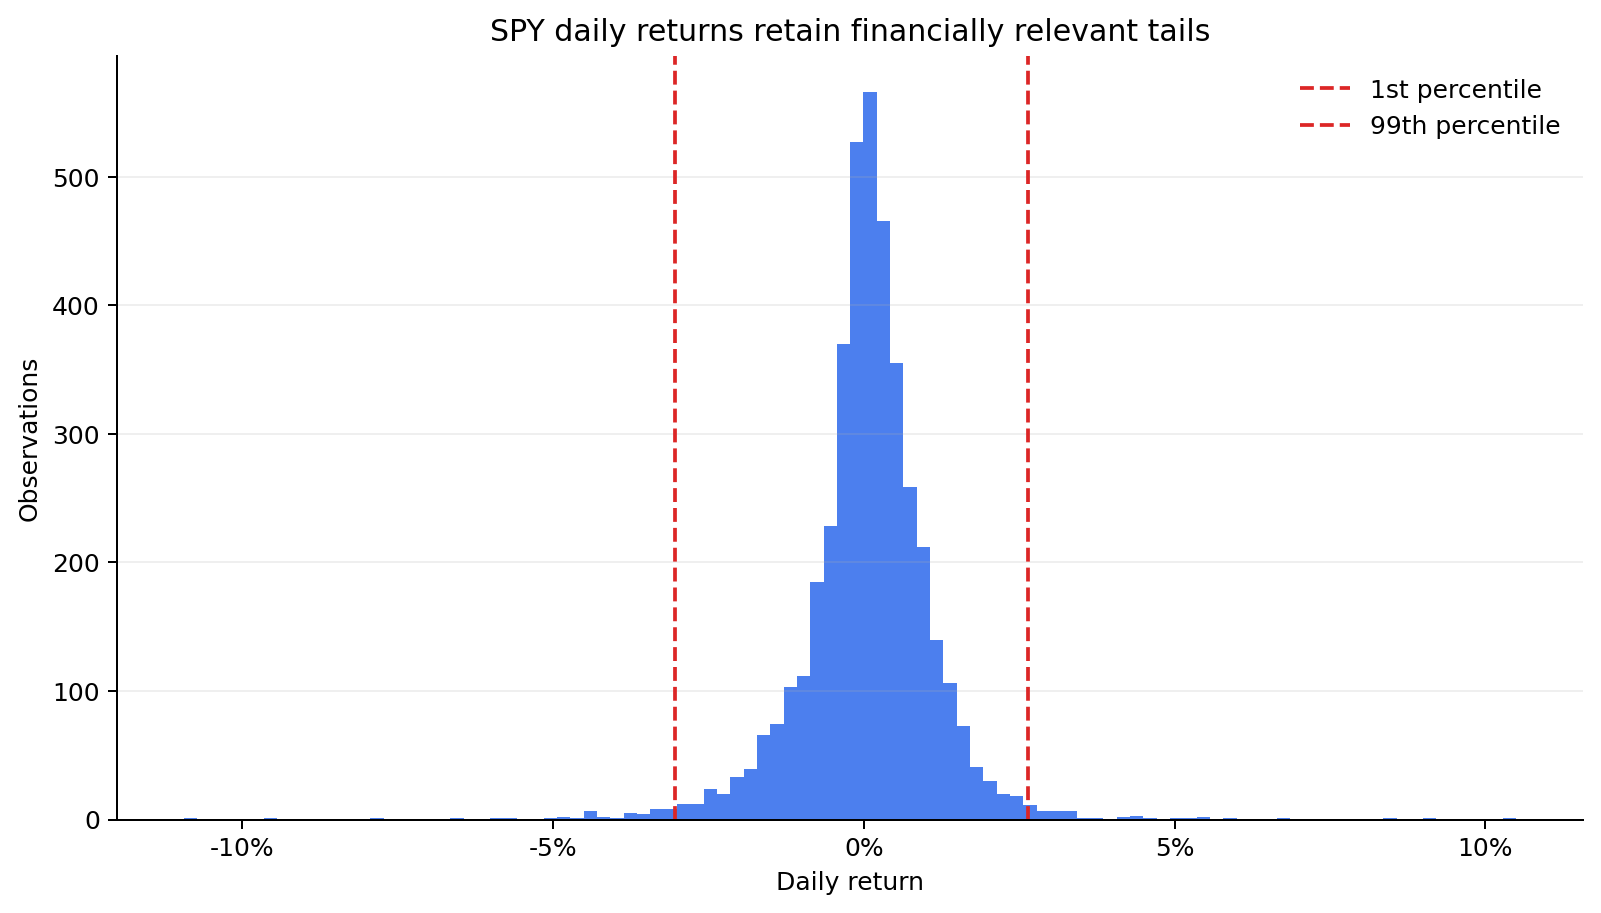

In [18]:
display(Image(filename=str(ROOT / "reports/images/return_distribution.png"), width=800))

## 9. Chronological model evaluation

In [19]:
regression = metrics["models"]["regression"]
regression_table = pd.DataFrame(
    {
        "Ridge": regression["ridge"],
        "Recent-vol baseline": regression["recent_volatility_baseline"],
        "Historical-mean baseline": regression["historical_mean_baseline"],
    }
).T
display(regression_table.round(4))
print(
    f"Ridge MAE improvement vs recent-vol baseline: {regression['ridge_mae_improvement_vs_recent']:.1%}"
)

,mae,rmse,r2
Ridge,0.0399,0.0656,0.3383
Recent-vol baseline,0.0506,0.0863,-0.1453
Historical-mean baseline,0.0516,0.0819,-0.0336


Ridge MAE improvement vs recent-vol baseline: 21.2%


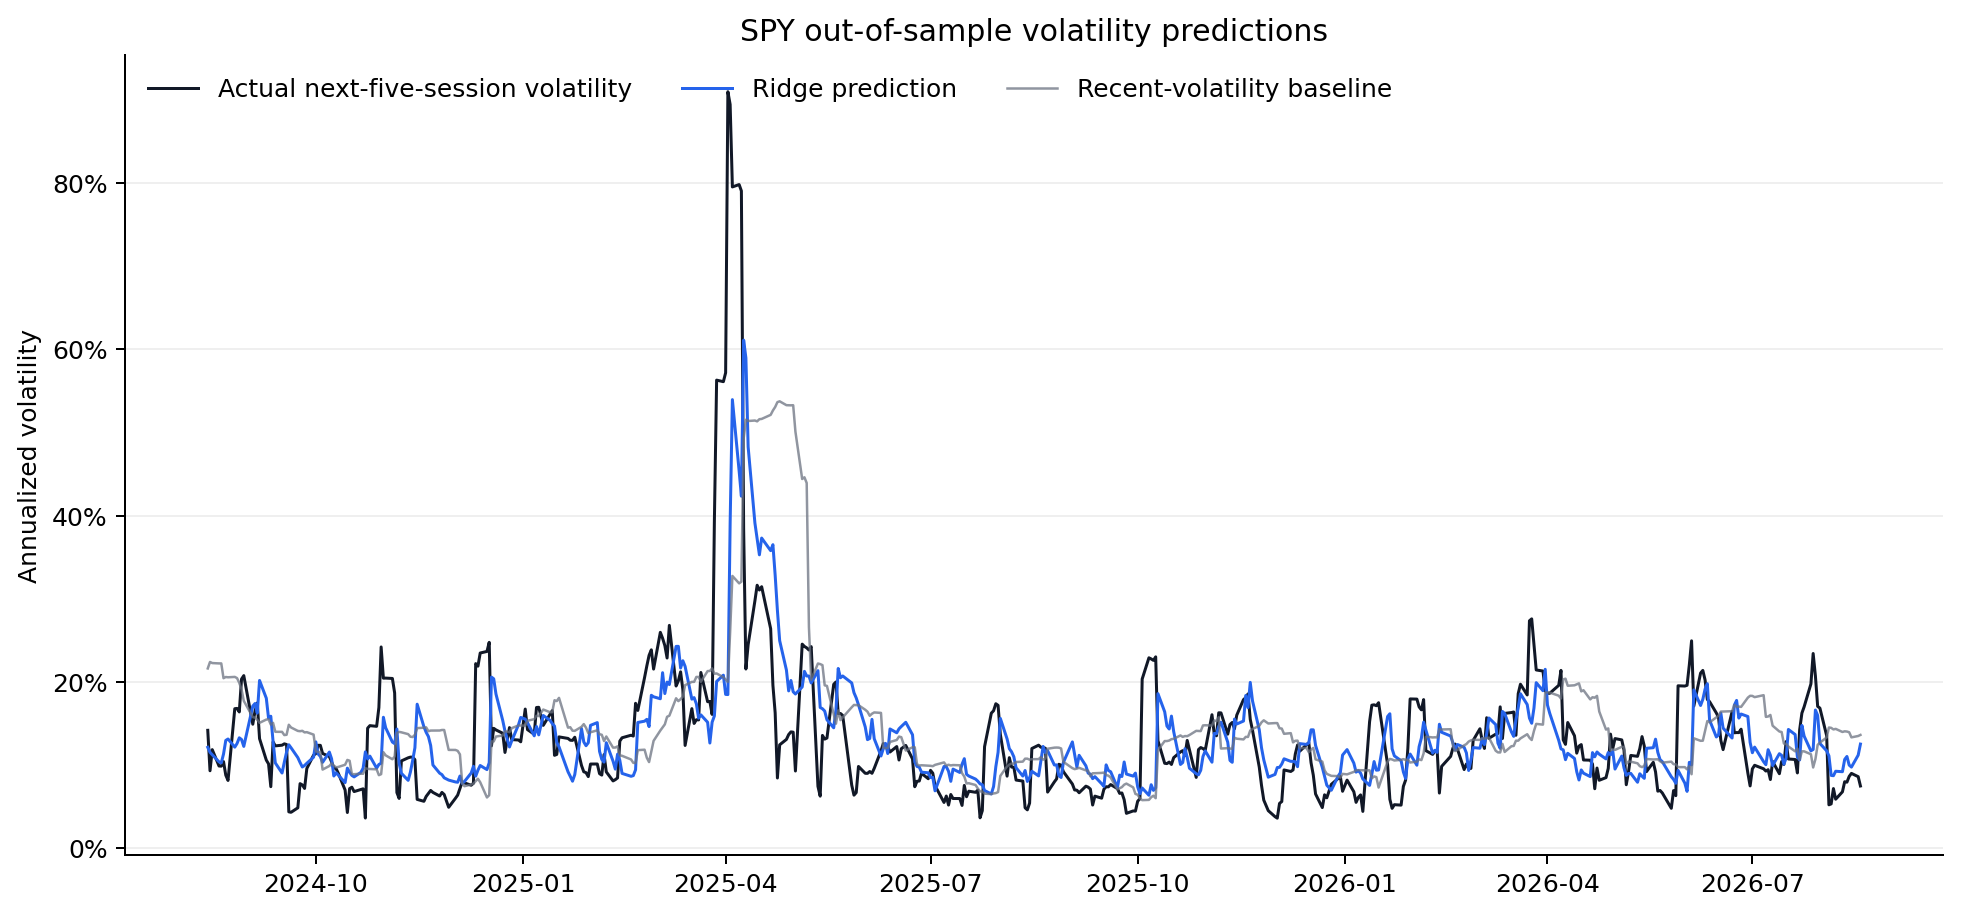

In [20]:
display(Image(filename=str(ROOT / "reports/images/regression_predictions.png"), width=900))

The split is chronological and purged. Because each target uses the next five sessions, a five-row embargo prevents any training target from containing a holdout date. The recent-volatility baseline represents the simple time-series answer; Ridge must improve on it to justify added complexity.

In [21]:
pd.Series(
    {
        "Training rows": metrics["models"]["train_rows"],
        "Training end": metrics["models"]["train_end"],
        "Embargo sessions": metrics["models"]["embargo_rows"],
        "Holdout start": metrics["models"]["test_start"],
        "Holdout forecast windows": metrics["models"]["test_rows"],
    },
    name="value",
).to_frame()

,value
Training rows,3339
Training end,2023-04-10
Embargo sessions,5
Holdout start,2023-04-18
Holdout forecast windows,837


In [22]:
classification = metrics["models"]["classification"]
classification_table = pd.DataFrame(
    {
        "Logistic model": classification["logistic"],
        "Prior baseline": classification["prior_baseline"],
    }
).T
display(classification_table.round(3))
print(classification["score_interpretation"])

,accuracy,balanced_accuracy,precision,recall,f1,mean_risk_score,brier_score,log_loss,roc_auc
Logistic model,0.812,0.724,0.372,0.604,0.46,0.337,0.142,0.460,0.779
Prior baseline,0.867,0.500,0.000,0.000,0.00,0.250,0.129,0.433,0.500


Class-weighted logistic output used for ranking and the decision rule; it is not a calibrated event probability.


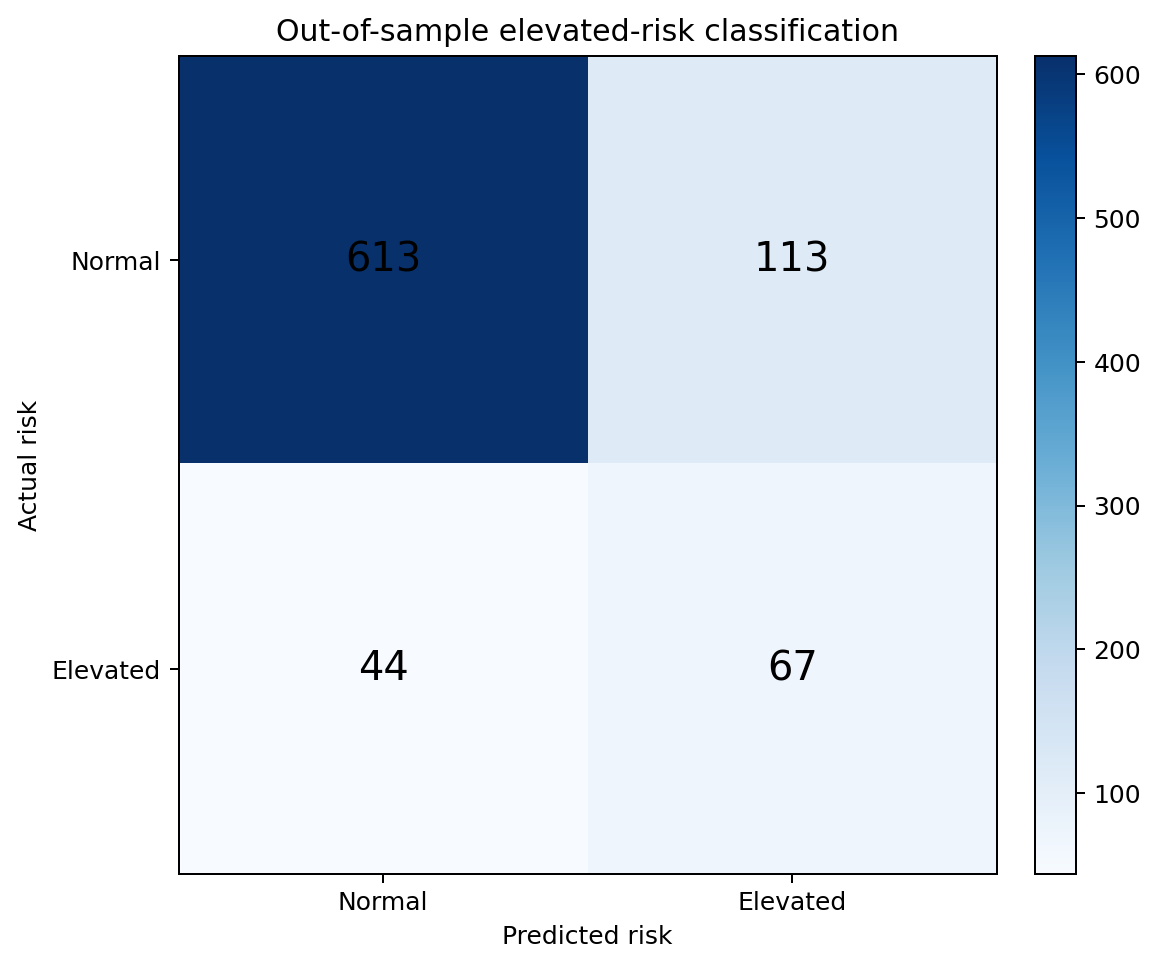

In [23]:
display(Image(filename=str(ROOT / "reports/images/classification_confusion_matrix.png"), width=600))

## 10. Robustness across non-overlapping windows and regimes

Adjacent daily five-session targets overlap. Each offset below samples every fifth holdout row, producing five non-overlapping sequences rather than calling all 835 observations independent weeks.

In [24]:
non_overlap = pd.DataFrame(metrics["models"]["diagnostics"]["non_overlapping_windows"])
display(non_overlap.round(3))

,offset,rows,elevated_windows,ridge_mae,ridge_mae_improvement_vs_recent,balanced_accuracy,recall
0,0,168,21,0.039,0.237,0.731,0.619
1,1,168,21,0.041,0.171,0.687,0.524
2,2,167,22,0.041,0.193,0.762,0.682
3,3,167,23,0.039,0.230,0.731,0.609
4,4,167,24,0.040,0.228,0.708,0.583


In [25]:
yearly = pd.DataFrame(metrics["models"]["diagnostics"]["calendar_year"])
display(yearly.round(3))

,year,rows,elevated_rate,ridge_mae,recent_volatility_baseline_mae,balanced_accuracy,recall,roc_auc
0,2023,178,0.045,0.030,0.030,0.564,0.375,0.685
1,2024,252,0.107,0.036,0.043,0.618,0.333,0.797
2,2025,250,0.192,0.054,0.075,0.828,0.833,0.842
3,2026,157,0.178,0.034,0.047,0.717,0.536,0.730


Year-by-year recall varies materially, so the aggregate score does not imply stable behavior in every regime. The expanding-window test below repeatedly refits on the past, keeps a five-session embargo, and evaluates the next block.

In [26]:
walk_forward = metrics["models"]["diagnostics"]["walk_forward"]
display(pd.DataFrame(walk_forward["folds"]).round(3))
display(pd.Series(walk_forward["aggregate"], name="aggregate").to_frame())

,fold,train_rows,test_rows,train_end,test_start,test_end,ridge_mae,ridge_mae_improvement_vs_recent,balanced_accuracy,recall
0,1,832,836,2013-04-24,2013-05-02,2016-08-24,0.038,0.212,0.707,0.476
1,2,1668,836,2016-08-17,2016-08-25,2019-12-19,0.042,0.129,0.762,0.672
2,3,2504,836,2019-12-12,2019-12-20,2023-04-18,0.063,0.190,0.755,0.856
3,4,3340,836,2023-04-11,2023-04-19,2026-08-18,0.040,0.212,0.725,0.604


,aggregate
rows,3344.000000
ridge_mae,0.045700
ridge_mae_improvement_vs_recent,0.186566
balanced_accuracy,0.791365
recall,0.738796
roc_auc,0.863208


## 11. Residual, outlier, threshold, and feature-window sensitivity

In [27]:
display(pd.Series(metrics["models"]["diagnostics"]["residuals"], name="value").to_frame().round(4))
display(pd.DataFrame(metrics["models"]["diagnostics"]["outlier_feature_ablation"]).T.round(4))

,value
mean_actual_minus_predicted,-0.0004
lag_1_autocorrelation,0.7470
highest_actual_vol_quartile_mean_actual_minus_predicted,0.0492
highest_actual_vol_quartile_mae,0.0721
top_actual_vol_decile_mean_actual_minus_predicted,0.0850
top_actual_vol_decile_mae,0.1210


,ridge_mae,balanced_accuracy,recall
with_flag,0.0399,0.7240,0.6036
without_flag,0.0401,0.7254,0.6036


Residuals remain serially correlated, and Ridge underpredicts the highest realized-volatility decile. The outlier flag has only a small incremental effect, so it should not be interpreted as the model's main driver.

In [28]:
sensitivity = pd.DataFrame(metrics["sensitivity"]["risk_threshold"])
formatted_sensitivity = sensitivity.copy()
for column in formatted_sensitivity.columns:
    formatted_sensitivity[column] = formatted_sensitivity[column].map(lambda value: f"{value:.1%}")
display(formatted_sensitivity)
display(pd.DataFrame(metrics["sensitivity"]["feature_windows"]).round(4))

,risk_quantile,risk_threshold_annualized_vol,balanced_accuracy,precision,recall,f1
0,70.0%,16.3%,71.2%,45.9%,59.0%,51.6%
1,75.0%,17.8%,72.4%,37.2%,60.4%,46.0%
2,80.0%,19.7%,72.7%,32.8%,57.1%,41.7%


,short_window_days,long_window_days,ridge_mae,ridge_mae_improvement_vs_recent,balanced_accuracy,recall
0,5,20,0.0399,0.2119,0.7240,0.6036
1,10,30,0.0405,0.2285,0.7272,0.6306
2,10,60,0.0415,0.2574,0.6904,0.5586


In [29]:
display(pd.Series(metrics["feature_relationships"], name="correlation").to_frame().round(3))

,correlation
volume_z_20_vs_current_rolling_vol_20,-0.082
volume_z_20_vs_absolute_daily_return,0.358
volume_z_20_vs_next_five_day_vol,0.182


Threshold and feature-window choices change precision, recall, and baseline improvement. Standardized volume is more related to absolute same-day return than to current rolling volatility; these are descriptive correlations, not causal claims.

## 12. Uncertainty: how precisely do we know the score?

In [30]:
uncertainty = metrics["uncertainty"]
ridge_ci = uncertainty["ridge_mae_bootstrap_ci"]
base_ci = uncertainty["baseline_mae_bootstrap_ci"]
ci_table = pd.DataFrame(
    [
        {
            "model": "Ridge",
            "MAE": ridge_ci["point_estimate"],
            "ci_low": ridge_ci["ci_low"],
            "ci_high": ridge_ci["ci_high"],
        },
        {
            "model": "Recent-volatility baseline",
            "MAE": base_ci["point_estimate"],
            "ci_low": base_ci["ci_low"],
            "ci_high": base_ci["ci_high"],
        },
    ]
)
display(ci_table.round(4))
print(
    "intervals overlap:",
    not (ridge_ci["ci_high"] < base_ci["ci_low"] or base_ci["ci_high"] < ridge_ci["ci_low"]),
)

,model,MAE,ci_low,ci_high
0,Ridge,0.0399,0.0366,0.0436
1,Recent-volatility baseline,0.0506,0.0461,0.0555


intervals overlap: False


In [31]:
scenarios = uncertainty["prediction_interval_scenarios"]
display(
    pd.DataFrame(scenarios).T[["lower_offset", "upper_offset", "residual_std", "method"]].round(4)
)

,lower_offset,upper_offset,residual_std,method
empirical_residual_percentiles,-0.089912,0.135299,0.065608,empirical residual percentiles
gaussian_approximation,-0.12895,0.128227,0.065608,gaussian approximation


The bootstrap intervals for Ridge and the baseline do not overlap, so the improvement is not an
artifact of which rows landed in the holdout. It quantifies how precisely the metric is known; it
does not establish that the model is correct.

The two prediction-interval scenarios answer a different question -- where a *new* observation may
land. They disagree because the residuals are right-skewed: the gaussian approximation is symmetric
and understates the upper tail, which is exactly the direction that matters for a risk monitor.

## 13. Current stakeholder signal

In [32]:
snapshot = metrics["latest_risk_snapshot"]
pd.Series(
    {
        "As-of date": snapshot["as_of_date"],
        "SPY adjusted close": f"${snapshot['adjusted_close']:,.2f}",
        "20-day annualized volatility": f"{snapshot['rolling_vol_20']:.1%}",
        "Predicted next-five-session volatility": f"{snapshot['predicted_next_five_day_vol']:.1%}",
        "Elevated-risk score": f"{snapshot['elevated_risk_score']:.1%}",
        "Decision cutoff": f"{snapshot['risk_score_cutoff']:.0%}",
        "All-history target threshold": f"{snapshot['risk_threshold_annualized_vol']:.1%}",
        "Classification": snapshot["risk_classification"].upper(),
        "Decision language": snapshot["decision_language"],
    },
    name="value",
).to_frame()

,value
As-of date,2026-08-25
SPY adjusted close,$765.91
20-day annualized volatility,13.3%
Predicted next-five-session volatility,11.3%
Elevated-risk score,25.1%
Decision cutoff,50%
All-history target threshold,17.1%
Classification,NORMAL
Decision language,The model does not flag elevated risk; maintai...


The current signal uses the separate production refit on all 4,175 labeled observations. Holdout metrics above remain tied to the purged evaluation fit.

## 14. Productization: refactor check and live API call

Stage 13 asks that the pipeline's steps move into reusable functions in `src/`, that they are
imported back here, and that the imported version is *checked against the original* before it goes
into the app. The original inline computation is kept above the imported one for exactly that reason.

In [33]:
# --- original: score the latest row inline, straight from the pipeline artifact ---
import joblib

from src.features import FEATURE_COLUMNS

model_dataset = read_dataframe(settings.processed_dir / "spy_model_dataset.parquet")
latest_row = model_dataset.dropna(subset=["date"]).iloc[-1]
inline_features = latest_row[FEATURE_COLUMNS].to_frame().T

pipeline_artifact = joblib.load(settings.model_dir / "risk_models.joblib")
inline_vol = float(pipeline_artifact["regression_model"].predict(inline_features)[0])
inline_score = float(pipeline_artifact["classification_model"].predict_proba(inline_features)[0, 1])
print(f"inline    predicted_vol={inline_vol:.10f}  risk_score={inline_score:.10f}")

inline    predicted_vol=0.1125118123  risk_score=0.2507283277


In [34]:
# --- imported: the same computation through the reusable serving function ---
from src.serving import load_model, predict_one

serving_bundle = load_model()
payload = {name: float(latest_row[name]) for name in FEATURE_COLUMNS}
served = predict_one(payload, serving_bundle)
print(
    f"imported  predicted_vol={served['predicted_next_five_day_vol']:.10f}  "
    f"risk_score={served['elevated_risk_score']:.10f}"
)

assert abs(served["predicted_next_five_day_vol"] - inline_vol) < 1e-9
assert abs(served["elevated_risk_score"] - inline_score) < 1e-9
print("refactor check PASSED - imported functions reproduce the inline cells exactly")

imported  predicted_vol=0.1125118123  risk_score=0.2507283277
refactor check PASSED - imported functions reproduce the inline cells exactly


### Calling the API from this notebook

The Flask app is started on an ephemeral port in a background thread, called with `requests`, then
shut down. The output below is the testing evidence Stage 13 asks to be left visible.

In [35]:
import json
import threading

import requests
from werkzeug.serving import make_server

from app import app as flask_app

server = make_server("127.0.0.1", 0, flask_app)  # port 0 -> OS picks a free one
port = server.server_port
thread = threading.Thread(target=server.serve_forever, daemon=True)
thread.start()
base = f"http://127.0.0.1:{port}"
print("API started on", base)

try:
    health = requests.get(f"{base}/health", timeout=10).json()
    print("GET /health ->", json.dumps(health, indent=2))

    response = requests.post(f"{base}/predict", json=payload, timeout=10)
    print(f"POST /predict -> HTTP {response.status_code}")
    print(json.dumps(response.json(), indent=2))

    bad = requests.post(f"{base}/predict", json={"return_lag_1": 0.01}, timeout=10)
    print(f"POST /predict (incomplete body) -> HTTP {bad.status_code}")
    print(json.dumps(bad.json(), indent=2))

    chart = requests.get(f"{base}/plot", timeout=10)
    print(
        f"GET /plot -> HTTP {chart.status_code}, {chart.headers['Content-Type']}, "
        f"{len(chart.content):,} bytes"
    )
finally:
    server.shutdown()
    thread.join(timeout=5)
    print("API stopped")

2026-08-28 07:23:26,301 INFO werkzeug 127.0.0.1 - - [28/Aug/2026 07:23:26] "GET /health HTTP/1.1" 200 -


2026-08-28 07:23:26,304 INFO risk_monitor.api scored observation: normal (0.2507)


2026-08-28 07:23:26,305 INFO werkzeug 127.0.0.1 - - [28/Aug/2026 07:23:26] "POST /predict HTTP/1.1" 200 -


2026-08-28 07:23:26,307 WARNING risk_monitor.api rejected request: missing required features: drawdown, ewma_vol_20, return_lag_5, return_outlier_flag, rolling_return_5, rolling_vol_20, rolling_vol_5, vol_ratio, volume_z_20


2026-08-28 07:23:26,307 INFO werkzeug 127.0.0.1 - - [28/Aug/2026 07:23:26] "POST /predict HTTP/1.1" 400 -


2026-08-28 07:23:26,308 INFO werkzeug 127.0.0.1 - - [28/Aug/2026 07:23:26] "GET /plot HTTP/1.1" 200 -


API started on http://127.0.0.1:63857
GET /health -> {
  "model_fit_end": "2026-08-18",
  "model_loaded": true,
  "model_path": "/Users/paritoshdwivedi/Downloads/project bootcamp/bootcamp_paritosh_dwivedi/project/model/model.pkl",
  "status": "ok"
}
POST /predict -> HTTP 200
{
  "elevated_risk_score": 0.2507283276886252,
  "model_fit_end": "2026-08-18",
  "predicted_next_five_day_vol": 0.11251181232228269,
  "risk_classification": "normal",
  "risk_score_cutoff": 0.5,
  "risk_threshold_annualized_vol": 0.17136329245241308,
  "score_interpretation": "Ranking and decision score, not a calibrated event probability."
}
POST /predict (incomplete body) -> HTTP 400
{
  "error": "missing required features: drawdown, ewma_vol_20, return_lag_5, return_outlier_flag, rolling_return_5, rolling_vol_20, rolling_vol_5, vol_ratio, volume_z_20"
}
GET /plot -> HTTP 200, image/png, 160,940 bytes
API stopped


### Monitoring dashboard wireframe (Stage 14)

`reports/images/dashboard_sketch.png` sketches the panels an operator would watch, one row per
monitoring layer, each panel naming its chart and its alert threshold.

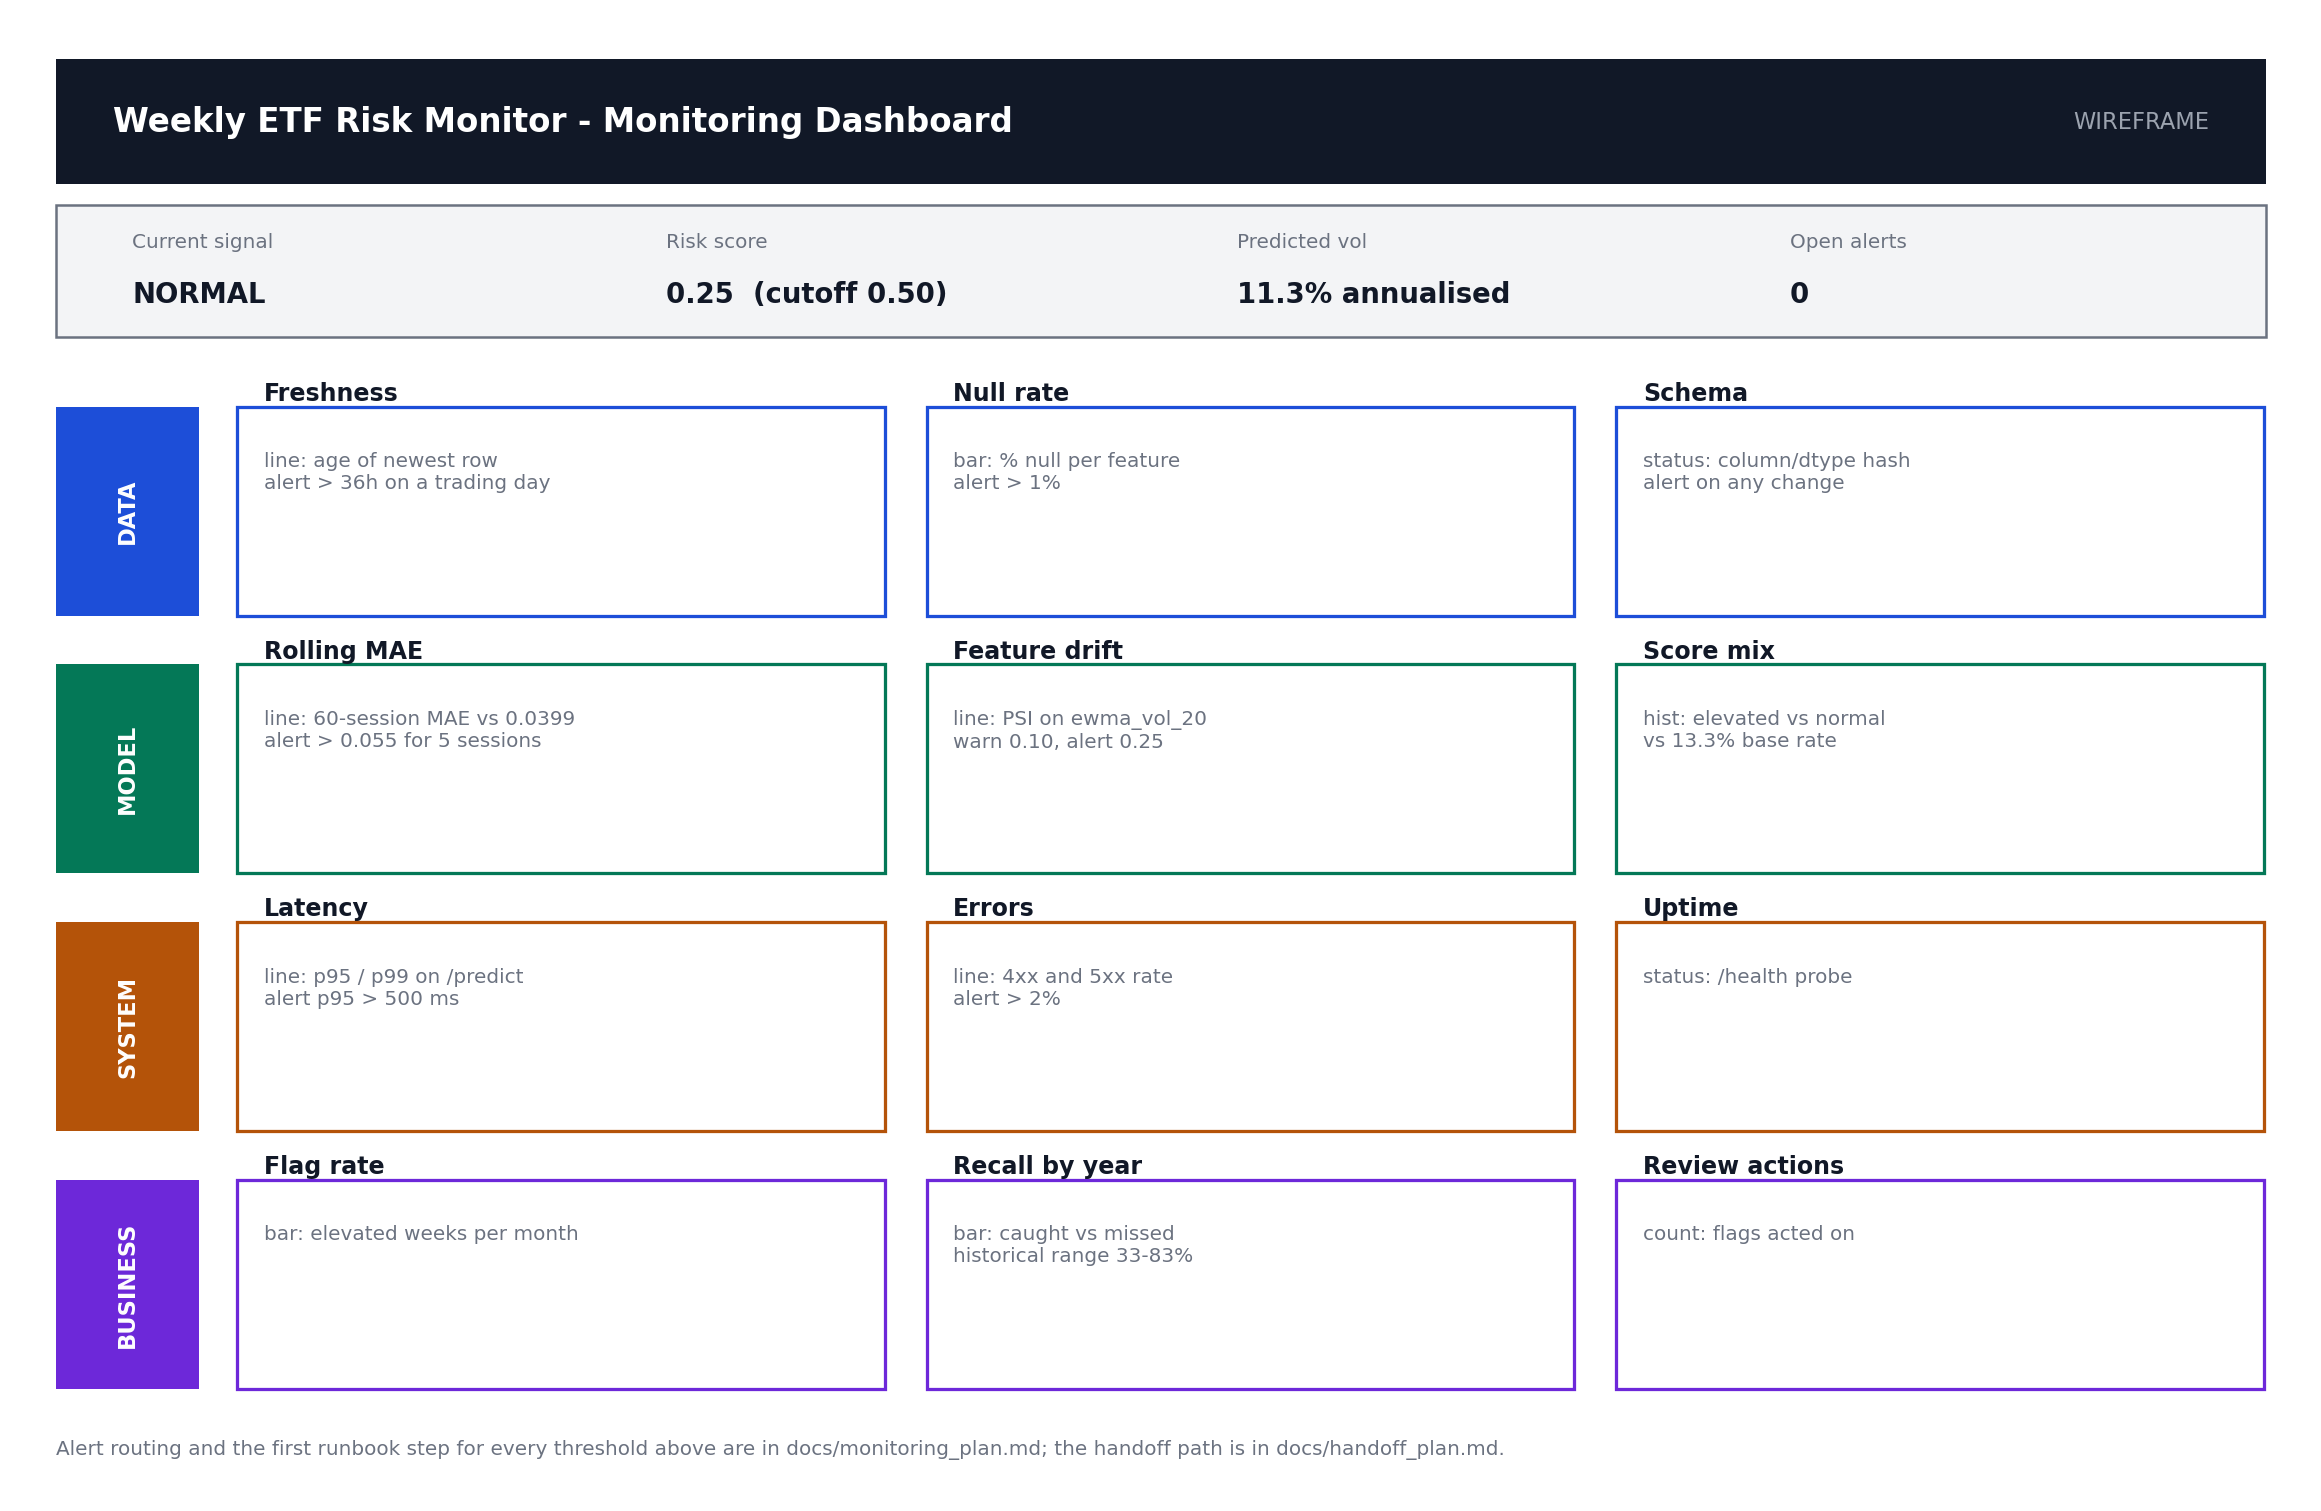

In [36]:
display(Image(filename=str(settings.images_dir / "dashboard_sketch.png")))

The API returns the same figures as the pipeline's own snapshot, an incomplete body is rejected with
**400** and a message naming every missing feature, and `/plot` serves the chart as a PNG. The served
answer and the analysed answer come from one function, so they cannot drift apart.

## 15. Assumptions, risks, and conclusion

- The five-trading-day horizon approximates a weekly review cycle.
- Provider data and adjusted prices may be revised after retrieval.
- Historical relationships can break during regime changes.
- The 75th-percentile label is training-derived and sensitive to the selected quantile.
- The class-weighted logistic output is a risk score, not a calibrated event probability.
- Ridge materially underpredicts the most volatile realized windows.
- A normal signal does not mean the position is safe; it means the model does not detect elevated relative risk under its historical definition.
- The output is decision support, not an automated trade or guarantee.

The final recommendation is stored in `reports/final_summary.md`. The complete assumptions and risk register are maintained under `docs/`.

In [37]:
print(snapshot["decision_language"])

The model does not flag elevated risk; maintain exposure only within the existing mandate.


## Next steps

- Revisit the target threshold if the stakeholder supplies an explicit risk limit.
- Monitor provider schema and model performance after each refresh.
- Add a benchmark ETF only if it improves the decision rather than expanding scope.
- Stop model expansion when added complexity does not improve chronological out-of-sample evidence.